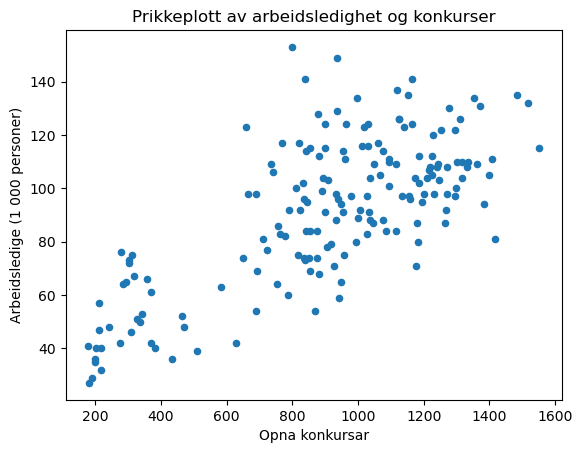

,Arbeidsledige (1 000 personer),Opna konkursar
Arbeidsledige (1 000 personer),1.000000,0.730791
Opna konkursar,0.730791,1.000000


In [41]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

konkurser_df = pd.read_csv("09695_20231018-104409.csv", sep="\t", encoding="ISO-8859-1")
konkurser_df.set_index("måned", inplace=True)
konkurser_df.index =konkurser_df.index.map(lambda x: datetime.datetime.strptime(x, "%YM%m"))
konkurser_df.index = konkurser_df.index.to_period("Q")
konkurser_df.index.name = "kvartal"
konkurser_df = konkurser_df.groupby(by="kvartal").sum()

arbeidsledige_df = pd.read_csv("08518_20231018-095706.csv", sep="\t")
arbeidsledige_df.set_index("kvartal", inplace=True)
arbeidsledige_df.index = arbeidsledige_df.index.map(lambda x: x.replace("K", "Q"))
arbeidsledige_df.index = pd.PeriodIndex(arbeidsledige_df.index, freq="Q")

df = pd.merge(left=arbeidsledige_df, right=konkurser_df, on="kvartal")
df.plot.scatter(y="Arbeidsledige (1 000 personer)", x="Opna konkursar")
plt.title("Prikkeplott av arbeidsledighet og konkurser")
plt.show()

display(df.corr())

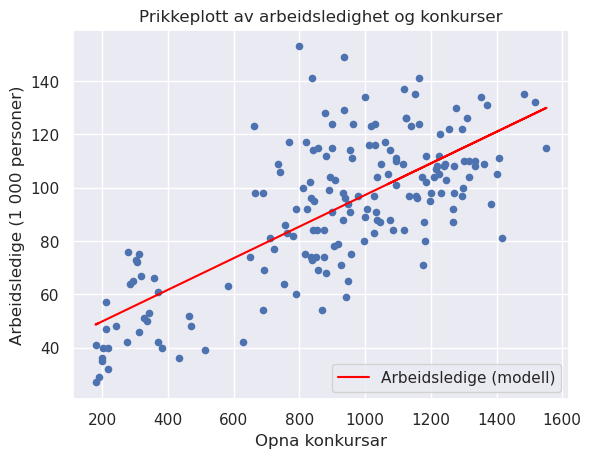

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


model = LinearRegression()
#X_train, X_test, y_train, y_test = train_test_split(df[["Opna konkursar"]], df["Arbeidsledige (1 000 personer), test_size=0.2)
model.fit(df[["Opna konkursar"]], df["Arbeidsledige (1 000 personer)"]) 

mse = mean_squared_error(df["Arbeidsledige (1 000 personer)"], df["Arbeidsledige (modell)"])


df["Arbeidsledige (modell)"] = model.predict(df[["Opna konkursar"]])
ax = df.plot.scatter(y="Arbeidsledige (1 000 personer)", x="Opna konkursar")
df.plot("Opna konkursar", "Arbeidsledige (modell)", ax=ax, color="red")
plt.title("Prikkeplott av arbeidsledighet og konkurser")
plt.show()

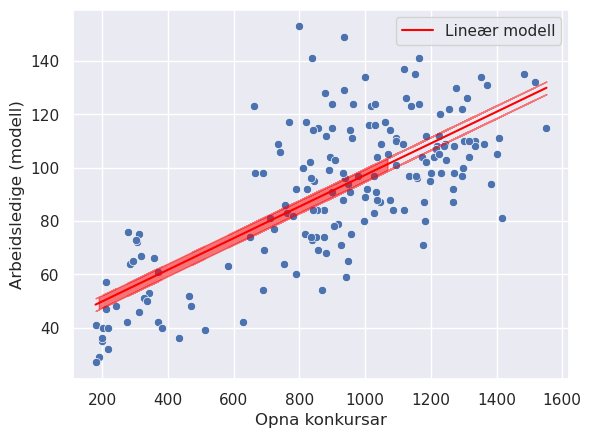

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import t

n = df.index.size
t_verdi = t.ppf(0.95, df=n-2)
SE = np.sqrt(mse)/np.sqrt(n)

df["konfidens øvre"] = df["Arbeidsledige (modell)"] + t_verdi*SE
df["konfidens nedre"] = df["Arbeidsledige (modell)"] -t_verdi*SE

sns.set_theme()
sns.lineplot(data=df, x="Opna konkursar", y="Arbeidsledige (modell)", color="red", legend=True, label="Lineær modell")
sns.scatterplot(data=df, x="Opna konkursar", y="Arbeidsledige (1 000 personer)")
plt.fill_between(df["Opna konkursar"], df["konfidens nedre"], df["konfidens øvre"], color="red", alpha=0.5)

plt.show()


<Axes: xlabel='Opna konkursar', ylabel='Arbeidsledige (1 000 personer)'>

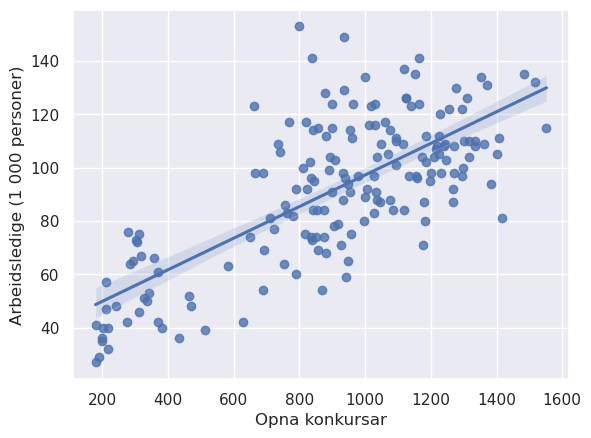

In [101]:
sns.regplot(data=df, x="Opna konkursar", y="Arbeidsledige (1 000 personer)", ci=95)